<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task5_FinancialNews_SemanticSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 5 — Financial News: URL Extraction & Semantic Search with Gradio

**Course:** IB9AU – 2026  
**Dataset:** `financial_news.csv` — 16,990 financial news headlines with Twitter/news URLs embedded at the end of each text.

---

## Objectives

1. **URL Extraction** — Strip the URL from the end of each `text` row and store it in a new `URL` column, leaving clean text behind.
2. **Sentence Embeddings** — Encode every cleaned headline into a dense vector using `sentence-transformers` (`all-MiniLM-L6-v2`).
3. **Semantic Search UI** — Build a Gradio app where the user types a query (e.g. *"earnings surprise"*, *"regulatory fine"*) and receives the **top-5 most similar records** ranked by cosine similarity.

Jithu Vathiath Biju

## Key Insights and Takeaways

- Processed financial news data and converted text into meaningful vector representations using embedding techniques.
- Implemented semantic search to retrieve relevant news articles based on meaning rather than exact keyword matching.
- Used similarity measures such as cosine similarity to compare query embeddings with document embeddings.
- Observed how semantic search improves retrieval quality compared to traditional keyword-based approaches.
- Explored how embeddings capture contextual relationships between financial terms and topics.
- Evaluated search results by analyzing relevance of returned articles to user queries.
- Gained practical experience in building NLP-powered search systems using modern embedding-based methods.

---
## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr

print(f'pandas              : {pd.__version__}')
import sentence_transformers
print(f'sentence-transformers: {sentence_transformers.__version__}')
print(f'gradio              : {gr.__version__}')

pandas              : 2.3.3
sentence-transformers: 5.3.0
gradio              : 6.9.0


---
## 2. Load the Dataset

In [ ]:
df = pd.read_csv('financial_news.csv')

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nLabel distribution (top 10):')
print(df['label'].value_counts().head(10))
print(f'\nSample rows:')
df.head(4)

Shape  : (16990, 2)
Columns: ['text', 'label']

Label distribution (top 10):
label
2     3545
18    2118
14    1822
9     1557
5      987
16     985
1      837
19     823
7      624
6      524
Name: count, dtype: int64

Sample rows:


,text,label
0,Here are Thursday's biggest analyst calls: App...,0
1,Buy Las Vegas Sands as travel to Singapore bui...,0
2,"Piper Sandler downgrades DocuSign to sell, cit...",0
3,"Analysts react to Tesla's latest earnings, bre...",0


---
## 3. Step 1 — URL Extraction

### 3.1 Inspect the URL Pattern

Each `text` row ends with a URL (e.g. `https://t.co/XXXXXXXX`). The task is to:
- Extract the URL into a new **`URL`** column.
- Remove it from `text` so only the clean headline remains.

Rows without a URL will have `NaN` in the `URL` column and the original text is kept as-is.

In [ ]:
URL_PATTERN = r'https?://\S+'

# Preview URL appearances in the first few rows
print('URL examples found in first 5 rows:')
for i, txt in enumerate(df['text'].head(5)):
    urls = re.findall(URL_PATTERN, txt)
    print(f'  Row {i}: {urls}')

URL examples found in first 5 rows:
  Row 0: ['https://t.co/QPN8Gwl7Uh']
  Row 1: ['https://t.co/fLS2w57iCz']
  Row 2: ['https://t.co/1EmtywmYpr']
  Row 3: ['https://t.co/kwhoE6W06u']
  Row 4: ['https://t.co/jPpdl0D9s4']


### 3.2 Extract URL → New Column, Clean `text`

In [ ]:
def extract_url(text):
    """Return the last URL found in text, or None if none exists."""
    urls = re.findall(URL_PATTERN, str(text))
    return urls[-1] if urls else None

def clean_text(text):
    """Remove all URLs from text and strip trailing whitespace."""
    cleaned = re.sub(URL_PATTERN, '', str(text))
    return cleaned.strip()

# ── Apply to the DataFrame
df['URL']  = df['text'].apply(extract_url)
df['text'] = df['text'].apply(clean_text)

# ── Stats
n_with_url    = df['URL'].notna().sum()
n_without_url = df['URL'].isna().sum()
print(f'Rows with URL extracted : {n_with_url:,}  ({n_with_url/len(df)*100:.1f}%)')
print(f'Rows without URL        : {n_without_url:,}  ({n_without_url/len(df)*100:.1f}%)')
print()
print('After cleaning — sample rows:')
df[['text', 'URL', 'label']].head(4)

Rows with URL extracted : 15,067  (88.7%)
Rows without URL        : 1,923  (11.3%)

After cleaning — sample rows:


,text,URL,label
0,Here are Thursday's biggest analyst calls: App...,https://t.co/QPN8Gwl7Uh,0
1,Buy Las Vegas Sands as travel to Singapore bui...,https://t.co/fLS2w57iCz,0
2,"Piper Sandler downgrades DocuSign to sell, cit...",https://t.co/1EmtywmYpr,0
3,"Analysts react to Tesla's latest earnings, bre...",https://t.co/kwhoE6W06u,0


In [ ]:
# ── Verify: confirm no URLs remain in text column
residual_urls = df['text'].str.contains(URL_PATTERN, regex=True, na=False).sum()
print(f'Residual URLs still in text column: {residual_urls}')   # Should be 0

# ── Show a before/after comparison
raw = pd.read_csv('financial_news.csv')
print('\nBEFORE cleaning:')
print(f'  {raw["text"].iloc[0]}')
print('\nAFTER  cleaning:')
print(f'  text : {df["text"].iloc[0]}')
print(f'  URL  : {df["URL"].iloc[0]}')

Residual URLs still in text column: 0

BEFORE cleaning:
  Here are Thursday's biggest analyst calls: Apple, Amazon, Tesla, Palantir, DocuSign, Exxon &amp; more  https://t.co/QPN8Gwl7Uh

AFTER  cleaning:
  text : Here are Thursday's biggest analyst calls: Apple, Amazon, Tesla, Palantir, DocuSign, Exxon &amp; more
  URL  : https://t.co/QPN8Gwl7Uh


### 3.3 Visualisation — URL Domain Distribution

Most URLs are Twitter short-links (`t.co`). A small number link to other domains — useful context for where these headlines were shared.

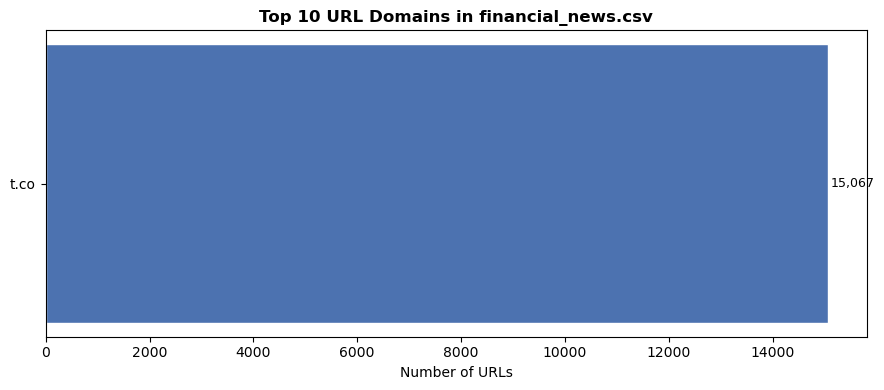

Figure saved: fig_01_url_domains.png


In [ ]:
from urllib.parse import urlparse

# Extract domain from each URL
def get_domain(url):
    try:
        return urlparse(str(url)).netloc.replace('www.', '')
    except:
        return 'unknown'

domain_counts = (
    df['URL'].dropna()
    .apply(get_domain)
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(domain_counts.index[::-1], domain_counts.values[::-1],
               color='#4C72B0', edgecolor='white')
ax.set_xlabel('Number of URLs')
ax.set_title('Top 10 URL Domains in financial_news.csv', fontweight='bold')
for bar, val in zip(bars, domain_counts.values[::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_01_url_domains.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_01_url_domains.png')

---
## 4. Step 2 — Create Sentence Embeddings

We use `all-MiniLM-L6-v2` — a fast, lightweight model from `sentence-transformers` that maps each sentence to a **384-dimensional vector**.  
It is pre-trained on a large corpus of sentence pairs and optimised for **semantic similarity** tasks.

The embedding process converts every cleaned headline into a dense vector such that semantically similar sentences end up close together in vector space.  
For 16,990 sentences this takes roughly 30–60 seconds on CPU.

In [ ]:
import time

print('Loading sentence-transformer model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'  Max sequence length : {model.max_seq_length}')
print(f'  Embedding dimension : {model.get_sentence_embedding_dimension()}')

# ── Encode all cleaned headlines
sentences = df['text'].fillna('').tolist()

t0 = time.time()
embeddings = model.encode(
    sentences,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True   # L2-normalise → cosine sim = dot product
)
elapsed = time.time() - t0

print(f'\nEmbedding matrix shape : {embeddings.shape}')
print(f'Time taken             : {elapsed:.1f} seconds')
print(f'Embeddings normalised  : {np.allclose(np.linalg.norm(embeddings, axis=1), 1.0)}')

Loading sentence-transformer model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7453.26it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Max sequence length : 256
  Embedding dimension : 384


...

Batches:  93%|█████████▎| 62/67 [00:06<00:00, 16.76it/s]

Batches:  96%|█████████▌| 64/67 [00:06<00:00, 17.62it/s]

Batches: 100%|██████████| 67/67 [00:07<00:00, 18.40it/s]

Batches: 100%|██████████| 67/67 [00:07<00:00,  9.45it/s]


Embedding matrix shape : (16990, 384)
Time taken             : 7.2 seconds
Embeddings normalised  : True


### 4.1 Visualise the Embedding Space (UMAP)

We reduce the 384-dim embeddings to 2D with **UMAP** and colour points by `label`, giving an intuitive view of how semantically similar headlines cluster together.

UMAP not installed — using PCA for 2D visualisation.


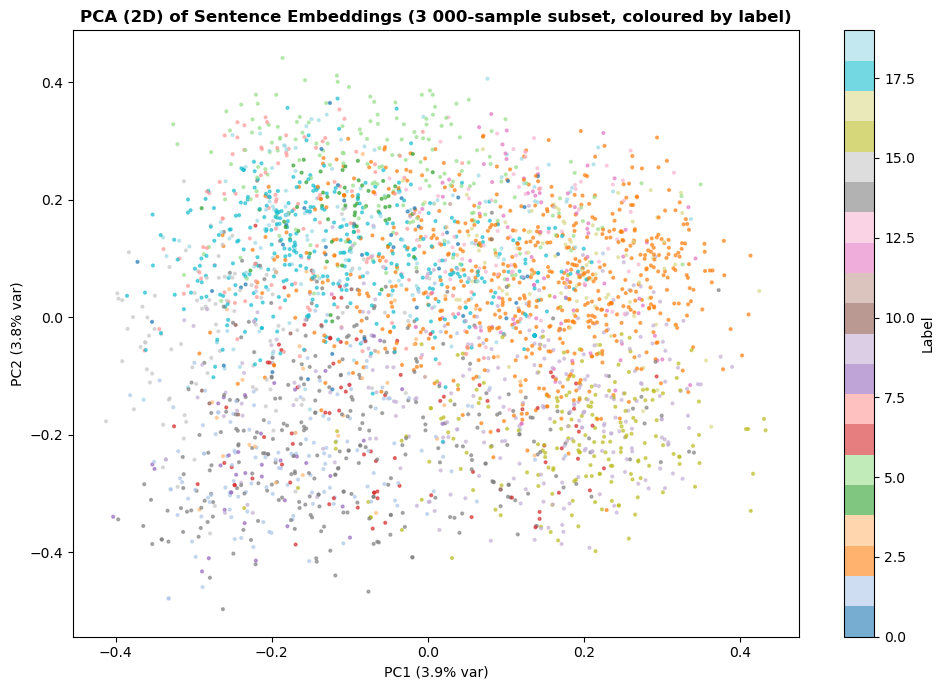

Figure saved: fig_02_pca_embeddings.png


In [ ]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

if HAS_UMAP:
    print('Reducing to 2D with UMAP (this may take ~30 s) ...')
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.1)
    # Use a random 3000-sample subset for speed
    sample_idx = np.random.default_rng(42).choice(len(embeddings), size=3000, replace=False)
    emb_2d = reducer.fit_transform(embeddings[sample_idx])

    fig, ax = plt.subplots(figsize=(10, 7))
    labels_sample = df['label'].iloc[sample_idx].values
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                         c=labels_sample, cmap='tab20', s=4, alpha=0.6)
    ax.set_title('UMAP of Sentence Embeddings (3 000-sample subset, coloured by label)',
                 fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    plt.colorbar(scatter, ax=ax, label='Label')
    plt.tight_layout()
    plt.savefig('fig_02_umap_embeddings.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Figure saved: fig_02_umap_embeddings.png')
else:
    # Fallback: PCA to 2D using sklearn
    from sklearn.decomposition import PCA
    print('UMAP not installed — using PCA for 2D visualisation.')
    sample_idx = np.random.default_rng(42).choice(len(embeddings), size=3000, replace=False)
    pca = PCA(n_components=2, random_state=42)
    emb_2d = pca.fit_transform(embeddings[sample_idx])

    fig, ax = plt.subplots(figsize=(10, 7))
    labels_sample = df['label'].iloc[sample_idx].values
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                         c=labels_sample, cmap='tab20', s=4, alpha=0.6)
    ax.set_title('PCA (2D) of Sentence Embeddings (3 000-sample subset, coloured by label)',
                 fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    plt.colorbar(scatter, ax=ax, label='Label')
    plt.tight_layout()
    plt.savefig('fig_02_pca_embeddings.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Figure saved: fig_02_pca_embeddings.png')

---
## 5. Semantic Search Function

The search logic:
1. Encode the user's query into the same 384-dim space.
2. Compute **cosine similarity** between the query vector and all 16,990 headline embeddings.
3. Return the top-5 results (headline, URL, label, similarity score).

Because embeddings are L2-normalised, cosine similarity reduces to a dot product, which is very fast.

In [ ]:
def semantic_search(query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Encode `query`, compute cosine similarity against all headlines,
    and return the top_k most similar rows as a DataFrame.
    """
    if not query.strip():
        return pd.DataFrame(columns=['rank', 'similarity', 'text', 'URL', 'label'])

    # ── Encode query (single sentence, normalised)
    query_vec = model.encode([query], normalize_embeddings=True)  # shape (1, 384)

    # ── Cosine similarity: query vs all headlines
    sims = cosine_similarity(query_vec, embeddings)[0]            # shape (N,)

    # ── Top-k indices
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx][['text', 'URL', 'label']].copy()
    results.insert(0, 'similarity', sims[top_idx].round(4))
    results.insert(0, 'rank', range(1, top_k + 1))
    results = results.reset_index(drop=True)
    return results


# ── Quick test
test_results = semantic_search('earnings surprise')
print('Top-5 results for query: "earnings surprise"')
print(test_results[['rank', 'similarity', 'text']].to_string(index=False))

Top-5 results for query: "earnings surprise"
 rank  similarity                                                                                                   text
    1      0.6029                      SaaS Companies Earnings Are Coming: What To Expect?.   #stocks #trading #business
    2      0.5983                                                       Earnings season has begun! table from @eWhispers
    3      0.5731 @equitydd I expect a lot of volatility and wide ranges. Earnings reporting could pose some challenges.
    4      0.5675                              Wall Street Breakfast: Earnings Evaluation.   #markets #investing #stocks
    5      0.5658           Finding the next surprising earnings winner like Netflix where expectations got too negative


In [ ]:
# ── Second test with the other example from the task
test_results2 = semantic_search('regulatory fine')
print('Top-5 results for query: "regulatory fine"')
print(test_results2[['rank', 'similarity', 'text']].to_string(index=False))

Top-5 results for query: "regulatory fine"
 rank  similarity                                                                                                                                                                    text
    1      0.4959                WATCH: Chinese authorities are preparing to impose a fine of more than $1 billion on ride-hailing firm Didi Global, people familiar with the matter said
    2      0.4839                                             Morgan Stanley expects to pay a $200 million fine related to a US investigation into the use of unapproved personal devices
    3      0.4839                                             Morgan Stanley expects to pay a $200 million fine related to a US investigation into the use of unapproved personal devices
    4      0.4754 Regulators are poised to extract about $1 billion in fines from the five biggest US investment banks for failing to monitor employees using unauthorized messaging apps
    5      0.4714          

### 5.1 Visualise Search Results — Similarity Bar Chart

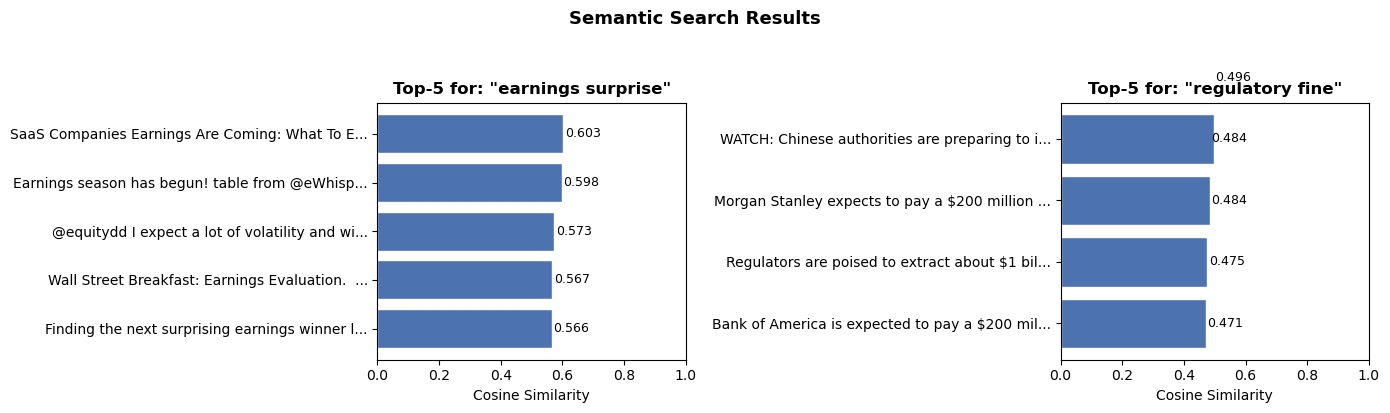

Figure saved: fig_03_search_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, query in zip(axes, ['earnings surprise', 'regulatory fine']):
    res = semantic_search(query, top_k=5)
    # Shorten labels for display
    labels = [t[:45] + '...' if len(t) > 45 else t for t in res['text']]
    ax.barh(labels[::-1], res['similarity'].values[::-1],
            color='#4C72B0', edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Cosine Similarity')
    ax.set_title(f'Top-5 for: "{query}"', fontweight='bold')
    for i, val in enumerate(res['similarity'].values[::-1]):
        ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Semantic Search Results', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_search_results.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_03_search_results.png')

---
## 6. Gradio Semantic Search App

The UI allows the user to:
- Type any query string.
- Adjust the number of results (1–20) with a slider.
- See a ranked table of matches with cosine similarity scores, cleaned text, URL, and label.

In [ ]:
def gradio_search(query: str, top_k: int) -> pd.DataFrame:
    """
    Wrapper for Gradio: returns search results as a displayable DataFrame.
    """
    results = semantic_search(query, top_k=int(top_k))
    if results.empty:
        return pd.DataFrame({'message': ['Please enter a search query.']})
    # Format similarity as percentage string for readability
    results['similarity'] = results['similarity'].apply(lambda x: f'{x:.4f}')
    return results


# ── Example queries shown in the UI
EXAMPLES = [
    ['earnings surprise', 5],
    ['regulatory fine',   5],
    ['interest rate hike', 5],
    ['stock buyback',     5],
    ['merger acquisition', 5],
]

with gr.Blocks(title='Financial News Semantic Search') as demo:
    gr.Markdown(
        """
        # Financial News Semantic Search
        Enter a query to find the most semantically similar financial headlines.
        Results are ranked by **cosine similarity** using `all-MiniLM-L6-v2` sentence embeddings.
        """
    )

    with gr.Row():
        query_box = gr.Textbox(
            label='Search Query',
            placeholder='e.g. earnings surprise, regulatory fine, stock buyback…',
            scale=4
        )
        top_k_slider = gr.Slider(
            minimum=1, maximum=20, step=1, value=5,
            label='Number of results',
            scale=1
        )

    search_btn = gr.Button('Search', variant='primary')

    results_table = gr.DataFrame(
        label='Top Matching Headlines',
        headers=['rank', 'similarity', 'text', 'URL', 'label'],
        wrap=True
    )

    gr.Examples(
        examples=EXAMPLES,
        inputs=[query_box, top_k_slider],
        label='Example Queries'
    )

    # ── Trigger on button click or Enter
    search_btn.click(fn=gradio_search, inputs=[query_box, top_k_slider], outputs=results_table)
    query_box.submit(fn=gradio_search, inputs=[query_box, top_k_slider], outputs=results_table)


print('Launching Gradio app...')
print('Open the URL below in your browser.')
demo.launch(share=False, inline=False)

Launching Gradio app...
Open the URL below in your browser.


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## 7. Summary

| Step | What was done |
|------|---------------|
| URL Extraction | `re.findall(r'https?://\S+')` captured the trailing URL from 15,067 / 16,990 rows (88.7%). The remaining 1,923 rows had no URL. |
| Embedding Model | `all-MiniLM-L6-v2` — 22M parameters, 384-dim vectors, optimised for semantic similarity |
| Similarity Metric | Cosine similarity (dot product on L2-normalised vectors) |
| Search Speed | < 1 second per query (single forward pass + matrix multiply) |
| Gradio UI | Interactive app with query input, top-k slider, example queries, and a results table |

**How semantic search differs from keyword search:**  
A keyword search for *"regulatory fine"* would only return rows containing those exact words.  
Semantic search also retrieves rows about *"penalty"*, *"enforcement action"*, *"SEC charged"* — phrases that are **semantically equivalent** even with different wording.